# Glass dataset: KPCA + LDA -> kNN and NCC

1. Loads the Glass dataset from `./glass/class.scale.txt` via `load_glass`.
2. Splits into train/test with stratification.
3. Applies **Kernel PCA (KPCA)** then **Linear Discriminant Analysis (LDA)** for dimensionality reduction.
4. Trains and evaluates:
   - **k-Nearest Neighbors (kNN)**
   - **Nearest Class Centroid (NCC / NearestCentroid)**

Notes:
- Glass is **multi-class** and **imbalanced**
- KPCA is unsupervised; LDA is supervised and is applied after KPCA.


Load libraries

In [19]:
import numpy as np
import time
import matplotlib.pyplot as plt

from data_loader import load_glass

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import KernelPCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
import pandas as pd

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix


In [2]:
# Load data
glass = load_glass("glass")
X, y = glass["x"], glass["y"]

feature_names = glass.get("feature_names", None)
class_names = glass.get("class_names", None)

print("X:", X.shape, "y:", y.shape)
print("mapped classes:", np.unique(y), "n_classes:", len(np.unique(y)))
if class_names is not None:
    print("class_names:", class_names)


X: (214, 9) y: (214,)
mapped classes: [0 1 2 3 4 5] n_classes: 6
class_names: {0: 'building_windows_float_processed', 1: 'building_windows_non_float_processed', 2: 'vehicle_windows_float_processed', 3: 'containers', 4: 'tableware', 5: 'headlamps'}


In [3]:
X[0]

array([-0.134323, -0.124812,  1.      , -0.495327, -0.296429, -0.980676,
       -0.3829  , -1.      , -1.      ])

In [4]:
# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=0,
    stratify=y
)
print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (149, 9) Test: (65, 9)


## Cross-validation strategy

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

## pipeline: StandardScaler -> KPCA -> LDA -> Classifier

Even though `class.scale.txt` is scaled, we keep `StandardScaler` for robustness.


In [ ]:
n_classes = len(np.unique(y_train))
lda_cap = n_classes - 1
print("n_classes:", n_classes, "| LDA cap (n_classes-1):", lda_cap)

kpca_dims = [2, 3, 5, 7, 9]

def valid_lda_components(kpca_n: int):
    # LDA n_components <= min(n_features_entering_LDA, n_classes-1)
    m = min(kpca_n, lda_cap)
    return list(range(1, m + 1)) if m >= 1 else [1]


for d in kpca_dims:
    print("kpca_n =", d, "-> lda__n_components:", valid_lda_components(d))

n_classes: 6 | LDA cap (n_classes-1): 5
kpca_n = 2 -> lda__n_components: [1, 2]
kpca_n = 3 -> lda__n_components: [1, 2, 3]
kpca_n = 5 -> lda__n_components: [1, 2, 3, 4, 5]
kpca_n = 7 -> lda__n_components: [1, 2, 3, 4, 5]
kpca_n = 9 -> lda__n_components: [1, 2, 3, 4, 5]


## 1) KPCA + LDA + kNN (Grid Search)

In [7]:
pipe_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("kpca", KernelPCA(fit_inverse_transform=False, random_state=0)),
    ("lda", LinearDiscriminantAnalysis()),
    ("clf", KNeighborsClassifier())
])


In [8]:
# Parameter grid
knn_param_grid = []

# RBF
for kpca_n in kpca_dims:
    knn_param_grid.append({
        "kpca__kernel": ["rbf"],
        "kpca__n_components": [kpca_n],
        "kpca__gamma": [0.1, 0.5, 1.0, 2.0, 5.0],
        "lda__n_components": valid_lda_components(kpca_n),
        "clf__n_neighbors": [1, 3, 5, 7, 9, 11, 15, 21],
        "clf__metric": ["euclidean", "manhattan"],
        "clf__weights": ["uniform", "distance"],
    })

# Polynomial
for kpca_n in kpca_dims:
    knn_param_grid.append({
        "kpca__kernel": ["poly"],
        "kpca__n_components": [kpca_n],
        "kpca__gamma": [0.1, 0.5, 1.0],
        "kpca__degree": [2, 3],
        "kpca__coef0": [0.0, 1.0],
        "lda__n_components": valid_lda_components(kpca_n),
        "clf__n_neighbors": [1, 3, 5, 7, 9, 11, 15, 21],
        "clf__metric": ["euclidean", "manhattan"],
        "clf__weights": ["uniform", "distance"],
    })

print("Total kNN candidates (param dicts):", len(knn_param_grid))


Total kNN candidates (param dicts): 10


In [9]:
knn_grid = GridSearchCV(
    estimator=pipe_knn,
    param_grid=knn_param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    error_score="raise"
)

start = time.perf_counter()
knn_grid.fit(X_train, y_train)
knn_time = time.perf_counter() - start

print("Best kNN params:")
print(knn_grid.best_params_)
print("Best CV f1_macro:", knn_grid.best_score_)
print(f"Grid search time: {knn_time:.2f} sec")


Best kNN params:
{'clf__metric': 'euclidean', 'clf__n_neighbors': 7, 'clf__weights': 'distance', 'kpca__gamma': 0.1, 'kpca__kernel': 'rbf', 'kpca__n_components': 7, 'lda__n_components': 4}
Best CV f1_macro: 0.681510434010434
Grid search time: 48.83 sec


In [10]:
best_knn = knn_grid.best_estimator_

y_pred_knn = best_knn.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred_knn)
f1m_knn = f1_score(y_test, y_pred_knn, average="macro")
f1w_knn = f1_score(y_test, y_pred_knn, average="weighted")

print("\n=== Test metrics (KPCA+LDA+kNN) ===")
print(f"Accuracy      : {acc_knn:.4f}")
print(f"F1 macro      : {f1m_knn:.4f}")
print(f"F1 weighted   : {f1w_knn:.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred_knn))

cm_knn = confusion_matrix(y_test, y_pred_knn)
print("Confusion matrix:\n", cm_knn)



=== Test metrics (KPCA+LDA+kNN) ===
Accuracy      : 0.6769
F1 macro      : 0.6085
F1 weighted   : 0.6863

Classification report:
              precision    recall  f1-score   support

           0       0.81      0.81      0.81        21
           1       0.64      0.70      0.67        23
           2       0.00      0.00      0.00         5
           3       0.50      0.50      0.50         4
           4       1.00      0.67      0.80         3
           5       1.00      0.78      0.88         9

    accuracy                           0.68        65
   macro avg       0.66      0.57      0.61        65
weighted avg       0.70      0.68      0.69        65

Confusion matrix:
 [[17  3  1  0  0  0]
 [ 1 16  5  1  0  0]
 [ 2  3  0  0  0  0]
 [ 0  2  0  2  0  0]
 [ 1  0  0  0  2  0]
 [ 0  1  0  1  0  7]]


In [20]:
cv_res = pd.DataFrame(knn_grid.cv_results_)

# Επιλογη χρησιμων στηλων (params + mean/std score + rank + fit time)
cols = (
    [c for c in cv_res.columns if c.startswith("param_")] +
    ["mean_test_score", "std_test_score", "rank_test_score",
     "mean_fit_time", "std_fit_time", "mean_score_time", "std_score_time"]
)

results_table = cv_res[cols].sort_values(["rank_test_score", "mean_test_score"], ascending=[True, False])

# πιο καθαρη εμφανιση
results_table = results_table.reset_index(drop=True)
results_table[["mean_test_score","std_test_score"]] = results_table[["mean_test_score","std_test_score"]].round(4)

# display(results_table)


# Top-5 configurations
display(results_table.head(5))

,param_clf__metric,param_clf__n_neighbors,param_clf__weights,param_kpca__gamma,param_kpca__kernel,param_kpca__n_components,param_lda__n_components,param_kpca__coef0,param_kpca__degree,mean_test_score,std_test_score,rank_test_score,mean_fit_time,std_fit_time,mean_score_time,std_score_time
0,euclidean,7,distance,0.1,rbf,7,4,NaN,NaN,0.6815,0.1285,1,0.010547,0.001110,0.007806,0.000258
1,euclidean,1,uniform,0.1,poly,7,5,1.0,2.0,0.6736,0.0980,2,0.006620,0.000063,0.006461,0.000120
2,euclidean,1,distance,0.1,poly,7,5,1.0,2.0,0.6736,0.0980,2,0.010265,0.001972,0.006749,0.001680
3,manhattan,5,distance,0.1,poly,7,4,1.0,2.0,0.6726,0.0913,4,0.009613,0.000162,0.008129,0.000909
4,manhattan,3,distance,0.1,rbf,7,4,NaN,NaN,0.6720,0.1231,5,0.009535,0.000861,0.007218,0.001335


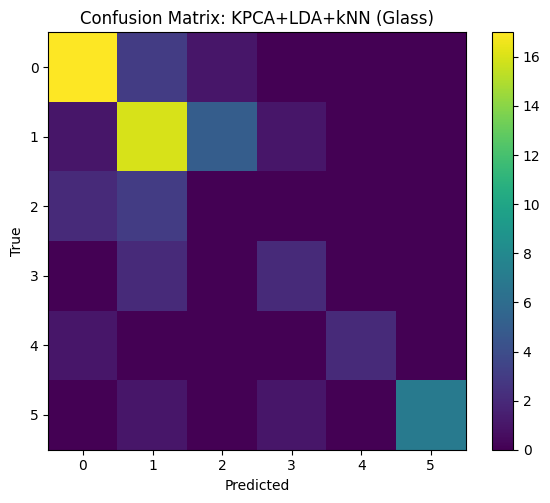

In [11]:
plt.figure(figsize=(6,5))
plt.imshow(cm_knn, interpolation="nearest")
plt.title("Confusion Matrix: KPCA+LDA+kNN (Glass)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.tight_layout()
plt.show()


## 2) KPCA + LDA + NCC (Grid Search)

In [12]:
pipe_ncc = Pipeline([
    ("scaler", StandardScaler()),
    ("kpca", KernelPCA(fit_inverse_transform=False, random_state=0)),
    ("lda", LinearDiscriminantAnalysis()),
    ("clf", NearestCentroid())
])


In [13]:
ncc_param_grid = []

# RBF
for kpca_n in kpca_dims:
    ncc_param_grid.append({
        "kpca__kernel": ["rbf"],
        "kpca__n_components": [kpca_n],
        "kpca__gamma": [0.1, 0.5, 1.0, 2.0, 5.0],
        "lda__n_components": valid_lda_components(kpca_n),
        "clf__metric": ["euclidean", "manhattan"],
        "clf__shrink_threshold": [None, 0.05, 0.1, 0.5, 1.0],
    })

# Polynomial
for kpca_n in kpca_dims:
    ncc_param_grid.append({
        "kpca__kernel": ["poly"],
        "kpca__n_components": [kpca_n],
        "kpca__gamma": [0.1, 0.5, 1.0],
        "kpca__degree": [2, 3],
        "kpca__coef0": [0.0, 1.0],
        "lda__n_components": valid_lda_components(kpca_n),
        "clf__metric": ["euclidean", "manhattan"],
        "clf__shrink_threshold": [None, 0.05, 0.1, 0.5, 1.0],
    })

print("Total NCC candidates (param dicts):", len(ncc_param_grid))


Total NCC candidates (param dicts): 10


In [14]:
ncc_grid = GridSearchCV(
    estimator=pipe_ncc,
    param_grid=ncc_param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    error_score="raise"
)

start = time.perf_counter()
ncc_grid.fit(X_train, y_train)
ncc_time = time.perf_counter() - start

print("Best NCC params:")
print(ncc_grid.best_params_)
print("Best CV f1_macro:", ncc_grid.best_score_)
print(f"Grid search time: {ncc_time:.2f} sec")


Best NCC params:
{'clf__metric': 'euclidean', 'clf__shrink_threshold': None, 'kpca__gamma': 0.1, 'kpca__kernel': 'rbf', 'kpca__n_components': 9, 'lda__n_components': 4}
Best CV f1_macro: 0.6318119216574594
Grid search time: 13.12 sec


In [15]:
best_ncc = ncc_grid.best_estimator_

y_pred_ncc = best_ncc.predict(X_test)
acc_ncc = accuracy_score(y_test, y_pred_ncc)
f1m_ncc = f1_score(y_test, y_pred_ncc, average="macro")
f1w_ncc = f1_score(y_test, y_pred_ncc, average="weighted")

print("\n=== Test metrics (KPCA+LDA+NCC) ===")
print(f"Accuracy      : {acc_ncc:.4f}")
print(f"F1 macro      : {f1m_ncc:.4f}")
print(f"F1 weighted   : {f1w_ncc:.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred_ncc))

cm_ncc = confusion_matrix(y_test, y_pred_ncc)
print("Confusion matrix:\n", cm_ncc)



=== Test metrics (KPCA+LDA+NCC) ===
Accuracy      : 0.5231
F1 macro      : 0.5591
F1 weighted   : 0.5775

Classification report:
              precision    recall  f1-score   support

           0       0.77      0.48      0.59        21
           1       0.60      0.52      0.56        23
           2       0.06      0.20      0.09         5
           3       0.75      0.75      0.75         4
           4       0.50      0.67      0.57         3
           5       1.00      0.67      0.80         9

    accuracy                           0.52        65
   macro avg       0.61      0.55      0.56        65
weighted avg       0.67      0.52      0.58        65

Confusion matrix:
 [[10  2  9  0  0  0]
 [ 1 12  8  0  2  0]
 [ 2  2  1  0  0  0]
 [ 0  1  0  3  0  0]
 [ 0  0  0  1  2  0]
 [ 0  3  0  0  0  6]]


In [21]:
cv_res = pd.DataFrame(ncc_grid.cv_results_)

# Επιλογη χρησιμων στηλων (params + mean/std score + rank + fit time)
cols = (
    [c for c in cv_res.columns if c.startswith("param_")] +
    ["mean_test_score", "std_test_score", "rank_test_score",
     "mean_fit_time", "std_fit_time", "mean_score_time", "std_score_time"]
)

results_table = cv_res[cols].sort_values(["rank_test_score", "mean_test_score"], ascending=[True, False])

# πιο καθαρη εμφανιση
results_table = results_table.reset_index(drop=True)
results_table[["mean_test_score","std_test_score"]] = results_table[["mean_test_score","std_test_score"]].round(4)

# display(results_table)


# Top-5 configurations
display(results_table.head(5))

,param_clf__metric,param_clf__shrink_threshold,param_kpca__gamma,param_kpca__kernel,param_kpca__n_components,param_lda__n_components,param_kpca__coef0,param_kpca__degree,mean_test_score,std_test_score,rank_test_score,mean_fit_time,std_fit_time,mean_score_time,std_score_time
0,euclidean,None,0.1,rbf,9,4,NaN,NaN,0.6318,0.0749,1,0.008602,0.002319,0.005261,0.000774
1,euclidean,0.05,0.1,rbf,9,4,NaN,NaN,0.6318,0.0749,1,0.007969,0.001424,0.006058,0.001506
2,euclidean,0.1,0.1,rbf,9,4,NaN,NaN,0.6318,0.0749,1,0.009019,0.001522,0.006261,0.001702
3,euclidean,0.1,0.1,rbf,9,5,NaN,NaN,0.6241,0.0743,4,0.009263,0.001373,0.006447,0.001414
4,euclidean,None,0.1,rbf,9,5,NaN,NaN,0.6238,0.0711,5,0.006944,0.000044,0.004448,0.000008


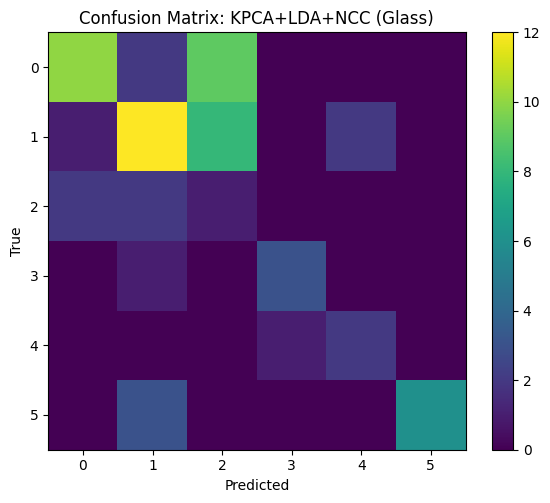

In [16]:
plt.figure(figsize=(6,5))
plt.imshow(cm_ncc, interpolation="nearest")
plt.title("Confusion Matrix: KPCA+LDA+NCC (Glass)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.tight_layout()
plt.show()


## Summary table

In [17]:
summary = [
    {
        "model": "KPCA+LDA+kNN",
        "cv_best_accuracy": knn_grid.best_score_,
        "test_accuracy": acc_knn,
        "test_f1_macro": f1m_knn,
        "test_f1_weighted": f1w_knn,
        "train_time_sec": knn_time,
        "best_params": knn_grid.best_params_,
    },
    {
        "model": "KPCA+LDA+NCC",
        "cv_best_accuracy": ncc_grid.best_score_,
        "test_accuracy": acc_ncc,
        "test_f1_macro": f1m_ncc,
        "test_f1_weighted": f1w_ncc,
        "train_time_sec": ncc_time,
        "best_params": ncc_grid.best_params_,
    }
]

for row in summary:
    print("\n" + row["model"])
    print(f"  CV best acc      : {row['cv_best_accuracy']:.4f}")
    print(f"  Test acc         : {row['test_accuracy']:.4f}")
    print(f"  Test F1 macro    : {row['test_f1_macro']:.4f}")
    print(f"  Test F1 weighted : {row['test_f1_weighted']:.4f}")
    print(f"  Train time (sec) : {row['train_time_sec']:.2f}")
    print(f"  Best params      : {row['best_params']}")



KPCA+LDA+kNN
  CV best acc      : 0.6815
  Test acc         : 0.6769
  Test F1 macro    : 0.6085
  Test F1 weighted : 0.6863
  Train time (sec) : 48.83
  Best params      : {'clf__metric': 'euclidean', 'clf__n_neighbors': 7, 'clf__weights': 'distance', 'kpca__gamma': 0.1, 'kpca__kernel': 'rbf', 'kpca__n_components': 7, 'lda__n_components': 4}

KPCA+LDA+NCC
  CV best acc      : 0.6318
  Test acc         : 0.5231
  Test F1 macro    : 0.5591
  Test F1 weighted : 0.5775
  Train time (sec) : 13.12
  Best params      : {'clf__metric': 'euclidean', 'clf__shrink_threshold': None, 'kpca__gamma': 0.1, 'kpca__kernel': 'rbf', 'kpca__n_components': 9, 'lda__n_components': 4}
